Loaded from local file.
first 10 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null 

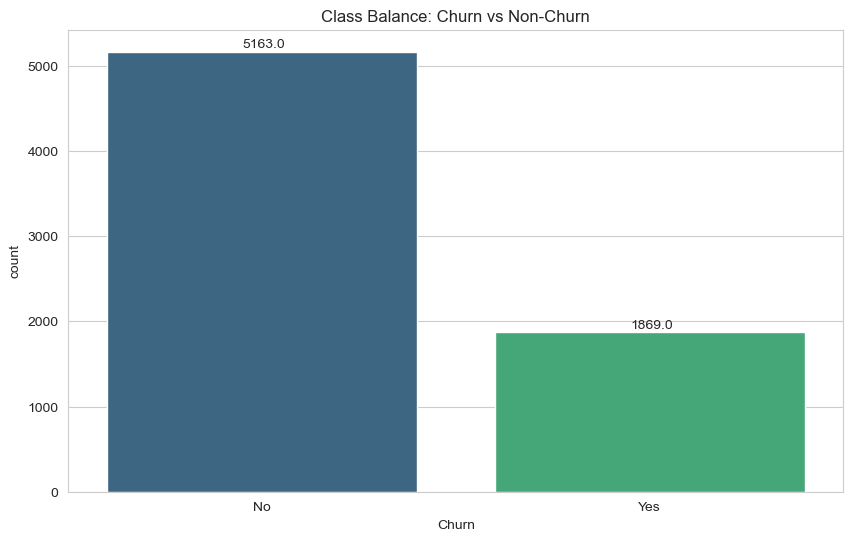

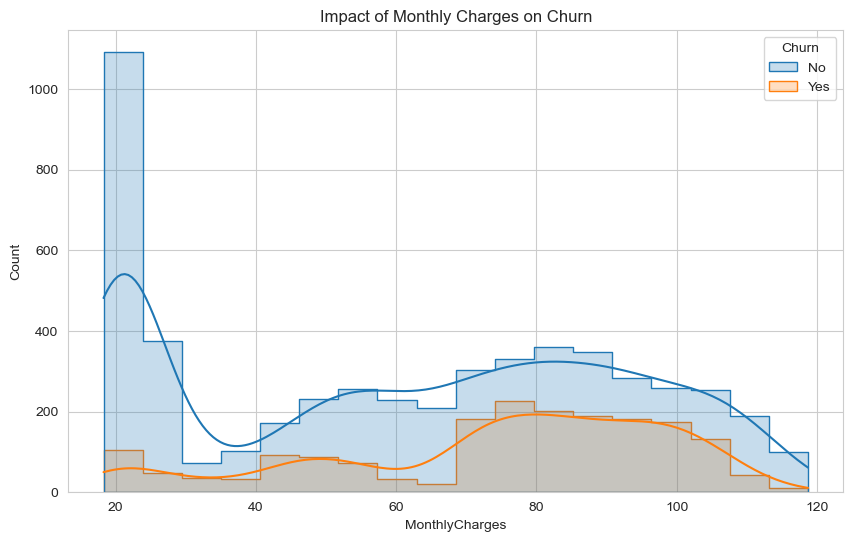

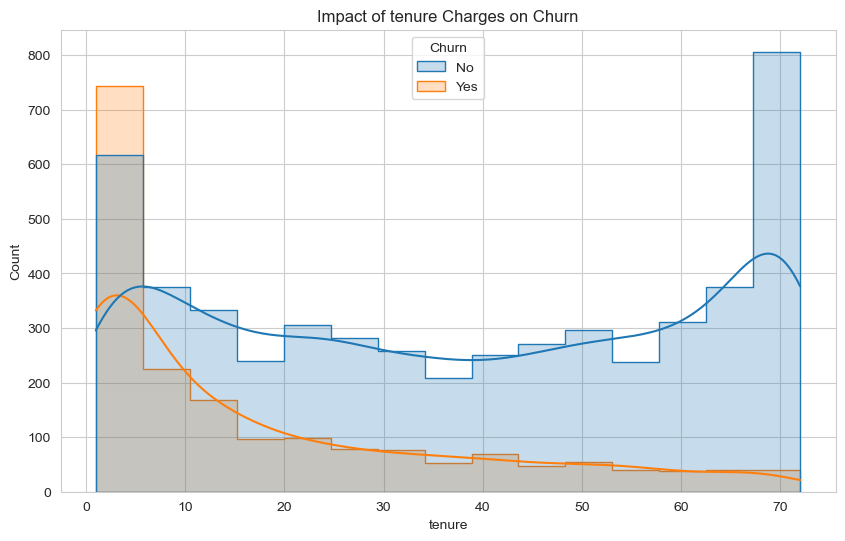

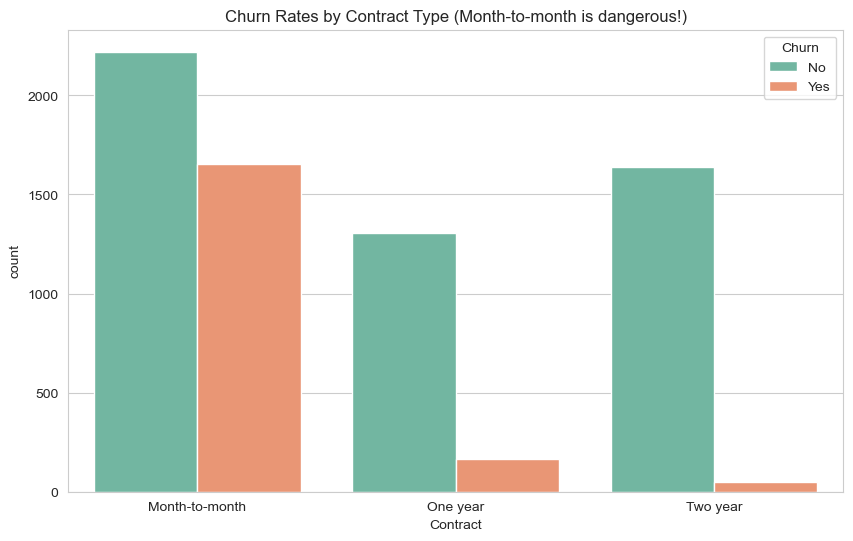

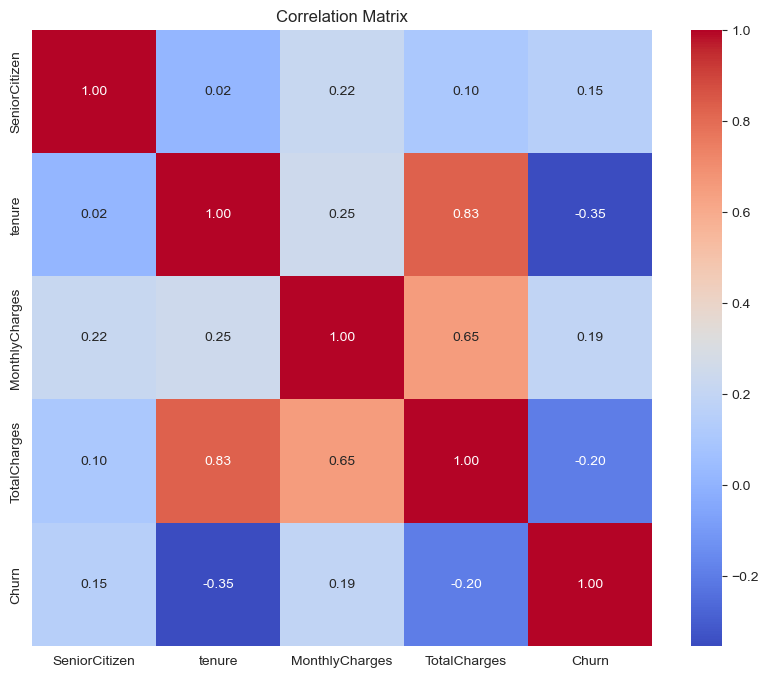

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

RAW_DATA_PATH = "data/raw/telco_churn.csv"


try:
	df = pd.read_csv(RAW_DATA_PATH)
	print("Loaded from local file.")
except:
	path = kagglehub.dataset_download("blastchar/telco-customer-churn")
	csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
	df = pd.read_csv(os.path.join(path, csv_file))
	print("Loaded from Kaggle cache.")


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)  

print("first 10 rows:")

display(df.head(10))

print("\nDataset Info:")
df.info()

# 3. Setup Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# --- VISUALIZATION 1: Target Variable (Churn) ---
plt.figure()
ax = sns.countplot(x="Churn", data=df, hue="Churn", palette="viridis")
plt.title("Class Balance: Churn vs Non-Churn")
# Add count labels
for p in ax.patches:
	ax.annotate(f"{p.get_height()}", (p.get_x() + 0.35, p.get_height() + 50))
plt.show()

# --- VISUALIZATION 2: Numerical Feature (Monthly Charges) ---
plt.figure()
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, element="step")
plt.title("Impact of Monthly Charges on Churn")
plt.show()

plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, element="step")
plt.title("Impact of tenure Charges on Churn")
plt.show()

# --- VISUALIZATION 3: Categorical Feature (Contract Type) ---
plt.figure()
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Churn Rates by Contract Type (Month-to-month is dangerous!)")
plt.show()

# --- VISUALIZATION 4: Correlation Matrix (Heatmap) ---
# We convert Yes/No to 1/0 just for this plot
corr_df = df.copy()
corr_df["Churn"] = corr_df["Churn"].map({"Yes": 1, "No": 0})
# Select only numeric columns
numeric_cols = corr_df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# feature_engineering.py
import pandas as pd
import numpy as np
import pickle
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- CONFIGURATION ---
RAW_DATA_PATH = "data/raw/telco_churn.csv"
PROCESSED_DATA_PATH = "data/processed"
MODEL_PATH = "outputModel"

# Create directories as per assignment structure
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs("data/raw", exist_ok=True)

print(">>> Step 3: Feature Engineering...")

# 1. SMART LOAD (Local or Download)
try:
    df = pd.read_csv(RAW_DATA_PATH)
    print("Loaded data from local file.")
except FileNotFoundError:
    print("Local file not found. Downloading via KaggleHub...")
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
    df = pd.read_csv(os.path.join(path, csv_file))
    df.to_csv(RAW_DATA_PATH, index=False)
    print(f"Data saved locally to {RAW_DATA_PATH}")

# 2. DATA CLEANING
# Drop ID [Assignment Note: irrelevant for prediction]
if 'customerID' in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Fix 'TotalCharges' (Coerce blanks to NaN, then impute)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 3. ENCODING
# Target: Yes/No -> 1/0
if df['Churn'].dtype == 'object':
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Features: One-Hot Encoding (drop_first to reduce multicollinearity)
df_processed = pd.get_dummies(df, drop_first=True)

# 4. SPLIT DATA
X = df_processed.drop("Churn", axis=1)
y = df_processed["Churn"]

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. SAVE ARTIFACTS (Crucial for App)
# Save Scaler
pickle.dump(scaler, open(f"{MODEL_PATH}/scaler.pkl", "wb"))

# Save Feature Names (Required to align user input in App)
feature_names = X.columns.tolist()
pickle.dump(feature_names, open(f"{MODEL_PATH}/features.pkl", "wb"))

# Save Data for Training Script
pickle.dump((X_train_scaled, y_train), open(f"{PROCESSED_DATA_PATH}/train_data.pkl", "wb"))
pickle.dump((X_test_scaled, y_test), open(f"{PROCESSED_DATA_PATH}/test_data.pkl", "wb"))

print("SUCCESS: Data processed. Artifacts saved to 'model/' folder.")

>>> Step 3: Feature Engineering...
Loaded data from local file.
SUCCESS: Data processed. Artifacts saved to 'model/' folder.


In [ ]:
# train_models_smote
import pandas as pd
import numpy as np
import pickle
import os
import time

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

# SMOTE (The Secret Weapon)
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    print("Error: imbalanced-learn is not installed.")
    print("Run: pip install imbalanced-learn")
    exit()

# --- CONFIGURATION ---
PROCESSED_DATA_PATH = "data/processed"
MODEL_PATH = "outputModel"

print(">>> Step 4: Training Models (with SMOTE)...")

# 1. LOAD DATA
try:
    X_train, y_train = pickle.load(open(f"{PROCESSED_DATA_PATH}/train_data.pkl", "rb"))
    X_test, y_test = pickle.load(open(f"{PROCESSED_DATA_PATH}/test_data.pkl", "rb"))
except FileNotFoundError:
    print("Error: Data not found.")
    exit()

# 2. APPLY SMOTE (Synthetic Minority Over-sampling Technique)
# This creates fake "Churners" to balance the training data perfectly 50/50
print("Applying SMOTE to balance the training set...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Original Training Size: {X_train.shape[0]}")
print(f"New Balanced Training Size: {X_train_resampled.shape[0]}")

# 3. DEFINE MODELS
# Note: We removed 'class_weight' because SMOTE already balanced the data!
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=5),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=42
    ),
    # XGBoost usually performs best with SMOTE
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
    ),
}

results = {}

# 4. TRAINING LOOP
for name, model in models.items():
    print(f"Training {name}...")

    # Train on RESAMPLED data
    model.fit(X_train_resampled, y_train_resampled)

    # Predict on ORIGINAL test data (Never SMOTE the test set!)
    y_pred = model.predict(X_test)
    y_prob = (
        model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    )

    # Metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    results[name] = metrics

    # Save Model
    filename = f"{MODEL_PATH}/{name.replace(' ', '_')}.pkl"
    pickle.dump(model, open(filename, "wb"))

print("\n" + "=" * 60)
print("FINAL COMPARISON TABLE (SMOTE)")
print("=" * 60)
results_df = pd.DataFrame(results).T
print(results_df)
results_df.to_csv("model_evaluation_report.csv")

>>> Step 4: Training Models (with SMOTE)...
Applying SMOTE to balance the training set...
Original Training Size: 5634
New Balanced Training Size: 8276
Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Naive Bayes...
Training Random Forest...
Training XGBoost...

FINAL COMPARISON TABLE (SMOTE)
                     Accuracy       AUC  Precision    Recall  F1 Score  \
Logistic Regression  0.755855  0.861186   0.524452  0.833780  0.643892   
Decision Tree        0.745209  0.846718   0.512195  0.788204  0.620908   
KNN                  0.709013  0.816137   0.471229  0.812332  0.596457   
Naive Bayes          0.667850  0.837658   0.437582  0.892761  0.587302   
Random Forest        0.790632  0.855403   0.586667  0.707775  0.641555   
XGBoost              0.799148  0.860635   0.601810  0.713137  0.652761   

                          MCC  
Logistic Regression  0.501849  
Decision Tree        0.465060  
KNN                  0.428837  
Naive Bayes          0.42